In [ ]:
from pathlib import Path
import json
import urllib.request
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    try:
        import ipykernel

        connection_file = Path(ipykernel.get_connection_file()).name
        kernel_id = connection_file.split('-', 1)[1].split('.', 1)[0]

        try:
            from notebook import notebookapp

            servers = list(notebookapp.list_running_servers())
        except Exception:
            from jupyter_server import serverapp

            servers = list(serverapp.list_running_servers())

        for srv in servers:
            token = srv.get('token', '')
            api_url = f"{srv['url'].rstrip('/')}/api/sessions"
            if token:
                api_url = f"{api_url}?token={token}"

            with urllib.request.urlopen(api_url, timeout=2) as response:
                sessions = json.loads(response.read().decode('utf-8'))

            for sess in sessions:
                if sess.get('kernel', {}).get('id') == kernel_id:
                    notebook_path = sess.get('notebook', {}).get('path') or sess.get('path', '')
                    raw_stem = Path(notebook_path).stem or 'notebook'
                    safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
                    return safe_stem.strip('_') or 'notebook'
    except Exception:
        pass

    return 'notebook'


if not hasattr(plt, '_trebl_autosave_original_show'):
    plt._trebl_autosave_original_show = plt.show
    plt._trebl_autosave_counter = 1
    plt._trebl_notebook_stem = _trebl_notebook_stem()

    def _trebl_autosave_show(*args, **kwargs):
        for fig_num in plt.get_fignums():
            fig = plt.figure(fig_num)
            stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
            fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
            plt._trebl_autosave_counter += 1
        return plt._trebl_autosave_original_show(*args, **kwargs)

    plt.show = _trebl_autosave_show


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300


In [68]:
gcn4_seq_df =pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/Table_S7_Full_length_ortholog_dataframe.csv")
gcn4_seq_df = gcn4_seq_df[["SpeciesName", "Seq", "Length"]]
gcn4_seq_df

,SpeciesName,Seq,Length
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943
...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251


In [69]:
gcn4_speeds = pd.read_csv("../../../output/GCN4_pipeline/speed/exponential_fit.csv", index_col = 0)[["ADseq", "A*k"]]
gcn4_speeds

,ADseq,A*k
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.103366
1,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.321955
2,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,0.317768
3,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.392171
5,AAEDSSKCPSTKAGTTEPDALFNWALDVACGADPIQQWTF,0.570139
...,...,...
1703,YSGHSKLEERGPHQVKATSEIYVDEKRNQNAYEWYGLDPE,0.238104
1704,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA,0.113521
1706,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS,0.771224
1707,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST,0.435958


In [70]:
def get_all_starts(full_seq, tile):
    starts = []
    start = 0
    while True:
        pos = full_seq.find(tile, start)
        if pos == -1:
            break
        starts.append(pos)
        start = pos + 1
    return starts

def get_coverage_stats(full_seq, speeds_df):
    mask = speeds_df['ADseq'].apply(lambda tile: tile in full_seq)
    matching = speeds_df[mask]
    
    if matching.empty:
        return pd.Series({
            'max_speed': None,
            'mean_speed': None,
            'median_speed': None,
            'top3_mean_speed': None,
            'speed_std': None,
            'tile_count': 0,
            'seq_length': len(full_seq),
            'coverage_fraction': 0.0
        })
    
    covered = set()
    for tile in matching['ADseq']:
        for start in get_all_starts(full_seq, tile):
            covered.update(range(start, start + len(tile)))
    
    speeds = matching['A*k']
    
    return pd.Series({
        'max_speed':       speeds.max(),
        'mean_speed':      speeds.mean(),
        'median_speed':    speeds.median(),
        'top3_mean_speed': speeds.nlargest(3).mean(),
        'speed_std':       speeds.std(),
        'tile_count':      len(matching),
        'seq_length':      len(full_seq),
        'coverage_fraction': len(covered) / len(full_seq)
    })


gcn4_seq_df = gcn4_seq_df.join(
    gcn4_seq_df['Seq'].apply(lambda seq: get_coverage_stats(seq, gcn4_speeds))
)

In [71]:
gcn4_seq_df

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928,0.859456,0.313531,0.219180,0.730380,0.211712,25.0,2928.0,0.118169
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.357170,0.293357,0.730380,0.212531,20.0,455.0,0.367033
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.377636,0.342019,0.730380,0.213053,18.0,222.0,0.549550
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.372114,0.338997,0.730380,0.208444,19.0,243.0,0.600823
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943,0.859456,0.313531,0.219180,0.730380,0.211712,25.0,2943.0,0.117567
...,...,...,...,...,...,...,...,...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,0.775677,0.346017,0.290099,0.563016,0.185031,10.0,242.0,0.442149
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.775677,0.353084,0.347163,0.630929,0.201050,13.0,260.0,0.615385
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239,0.533748,0.399025,0.399025,0.399025,0.190527,2.0,239.0,0.251046
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.411337,0.317208,0.317764,0.361528,0.075638,5.0,251.0,0.458167


In [72]:
gcn4_seq_df_with_max_speeds = gcn4_seq_df.dropna()
gcn4_seq_df_with_max_speeds

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
0,Sordariomycetes_jgi|Acral2|2019554|gm1.4974_g,MALRIEVYNRIESSTASTALQRQDLRYTFRSNARAASGQANANYQA...,2928,0.859456,0.313531,0.219180,0.730380,0.211712,25.0,2928.0,0.118169
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.357170,0.293357,0.730380,0.212531,20.0,455.0,0.367033
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.377636,0.342019,0.730380,0.213053,18.0,222.0,0.549550
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.372114,0.338997,0.730380,0.208444,19.0,243.0,0.600823
4,Sordariomycetes_jgi|Acral2|2047914|estExt_Gene...,MADTCGGSTPLKNFSQYGSQDRSLQQDRVVHGFHGSAAAGPSTFRS...,2943,0.859456,0.313531,0.219180,0.730380,0.211712,25.0,2943.0,0.117567
...,...,...,...,...,...,...,...,...,...,...,...
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,0.775677,0.346017,0.290099,0.563016,0.185031,10.0,242.0,0.442149
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.775677,0.353084,0.347163,0.630929,0.201050,13.0,260.0,0.615385
499,Mory_EHA48851.1_MagnaportheOryzae70_15,MNNTSDLGLDDFTAFGGGASAFPSPAMPGVFDIASTTASTMGTVSP...,239,0.533748,0.399025,0.399025,0.399025,0.190527,2.0,239.0,0.251046
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.411337,0.317208,0.317764,0.361528,0.075638,5.0,251.0,0.458167


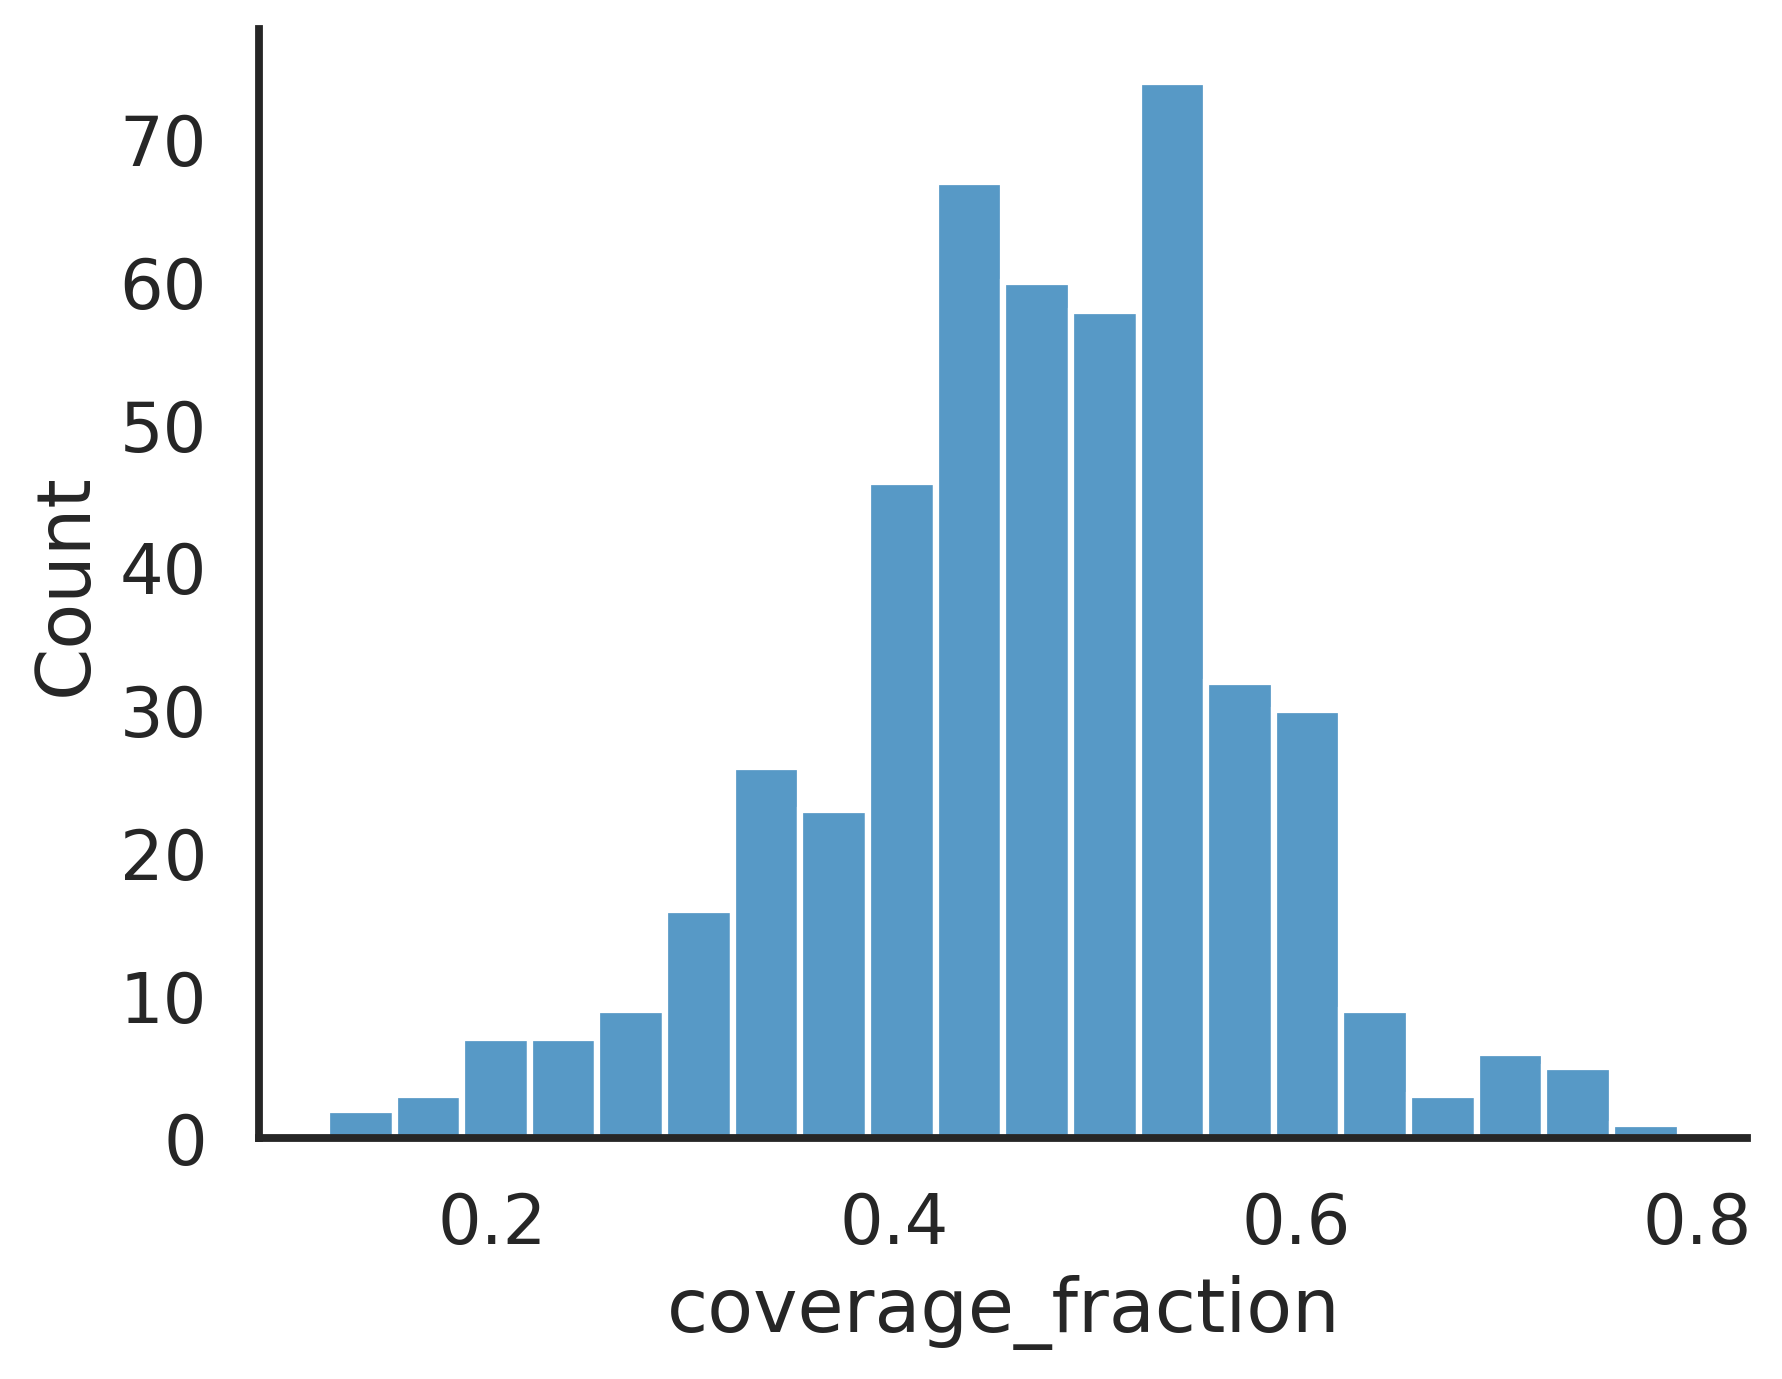

In [86]:
sns.histplot(gcn4_seq_df_with_max_speeds["coverage_fraction"])
sns.despine()

In [91]:
gcn4_seq_df_with_max_speeds_suffic_cov = gcn4_seq_df_with_max_speeds[gcn4_seq_df_with_max_speeds["coverage_fraction"] >= 0.3]
gcn4_seq_df_with_max_speeds_suffic_cov

,SpeciesName,Seq,Length,max_speed,mean_speed,median_speed,top3_mean_speed,speed_std,tile_count,seq_length,coverage_fraction
1,Sordariomycetes_jgi|Acral2|2027520|fgenesh1_pg...,MWLVVRAGPSPLLQDLAARCHIDGMSMPLLHFDPPDFPLTGVALGI...,455,0.859456,0.357170,0.293357,0.730380,0.212531,20.0,455.0,0.367033
2,Sordariomycetes_jgi|Acral2|2034848|fgenesh1_kg...,MSITELDDFTGFEGGASTAYSSPGAPAVFDLPGASNHVGTISPQDL...,222,0.859456,0.377636,0.342019,0.730380,0.213053,18.0,222.0,0.549550
3,Sordariomycetes_jgi|Acral2|2034849|fgenesh1_kg...,MSITGNYNQHFGAAGIISSHNYVLSELDDFTGFEGGASTAYSSPGA...,243,0.859456,0.372114,0.338997,0.730380,0.208444,19.0,243.0,0.600823
5,Sordariomycetes_jgi|Acral2|2105274|e_gw1.4.549.1,MSAPNSTALTALTSPSLYESPDFGYDVSPGFGSNDFDTGSNQWFSL...,170,0.859456,0.469729,0.492170,0.730380,0.256467,9.0,170.0,0.452941
6,Leotiomycetes_jgi|Amore1|20362|gm1.6031_g,MAWPPGLCSLESGRWFRLALDPGGGTALGSLCPLVCPAQWYAYVIG...,520,0.767166,0.382522,0.341399,0.681544,0.182615,16.0,520.0,0.444231
...,...,...,...,...,...,...,...,...,...,...,...
496,Anig_EHA26660.1_AspergillusNigerATCC1015,MSTPNIAQDFPELFDLQSNRFGDDLSSPESNMLSPQINTSFFSPMG...,245,0.875195,0.438562,0.397035,0.692591,0.295309,7.0,245.0,0.551020
497,Cimm_XP_012214147.1_CoccidioidesImmitisRS,MSTSNLPLDIGTLLDLSTDQFVEDLGSSSHSSLLDQDQLDQLINFN...,242,0.775677,0.346017,0.290099,0.563016,0.185031,10.0,242.0,0.442149
498,Cpos_XP_003070205.1_CoccidioidesPosadasiiC735,MSTSNLPLGMVSLSASAVRLVANQRPDIGTLLDLSTDQYVEDLGSS...,260,0.775677,0.353084,0.347163,0.630929,0.201050,13.0,260.0,0.615385
500,Nfis_EAW24893.1_NeosartoryaFischeriNRRL181,MSTPNIAQDMPDFFGLPSNDFGDDFELSTEPTMLSPNQIPTGLMAV...,251,0.411337,0.317208,0.317764,0.361528,0.075638,5.0,251.0,0.458167


Text(0.5, 0.95, 'GCN4 Full TF Speed Aggregation')

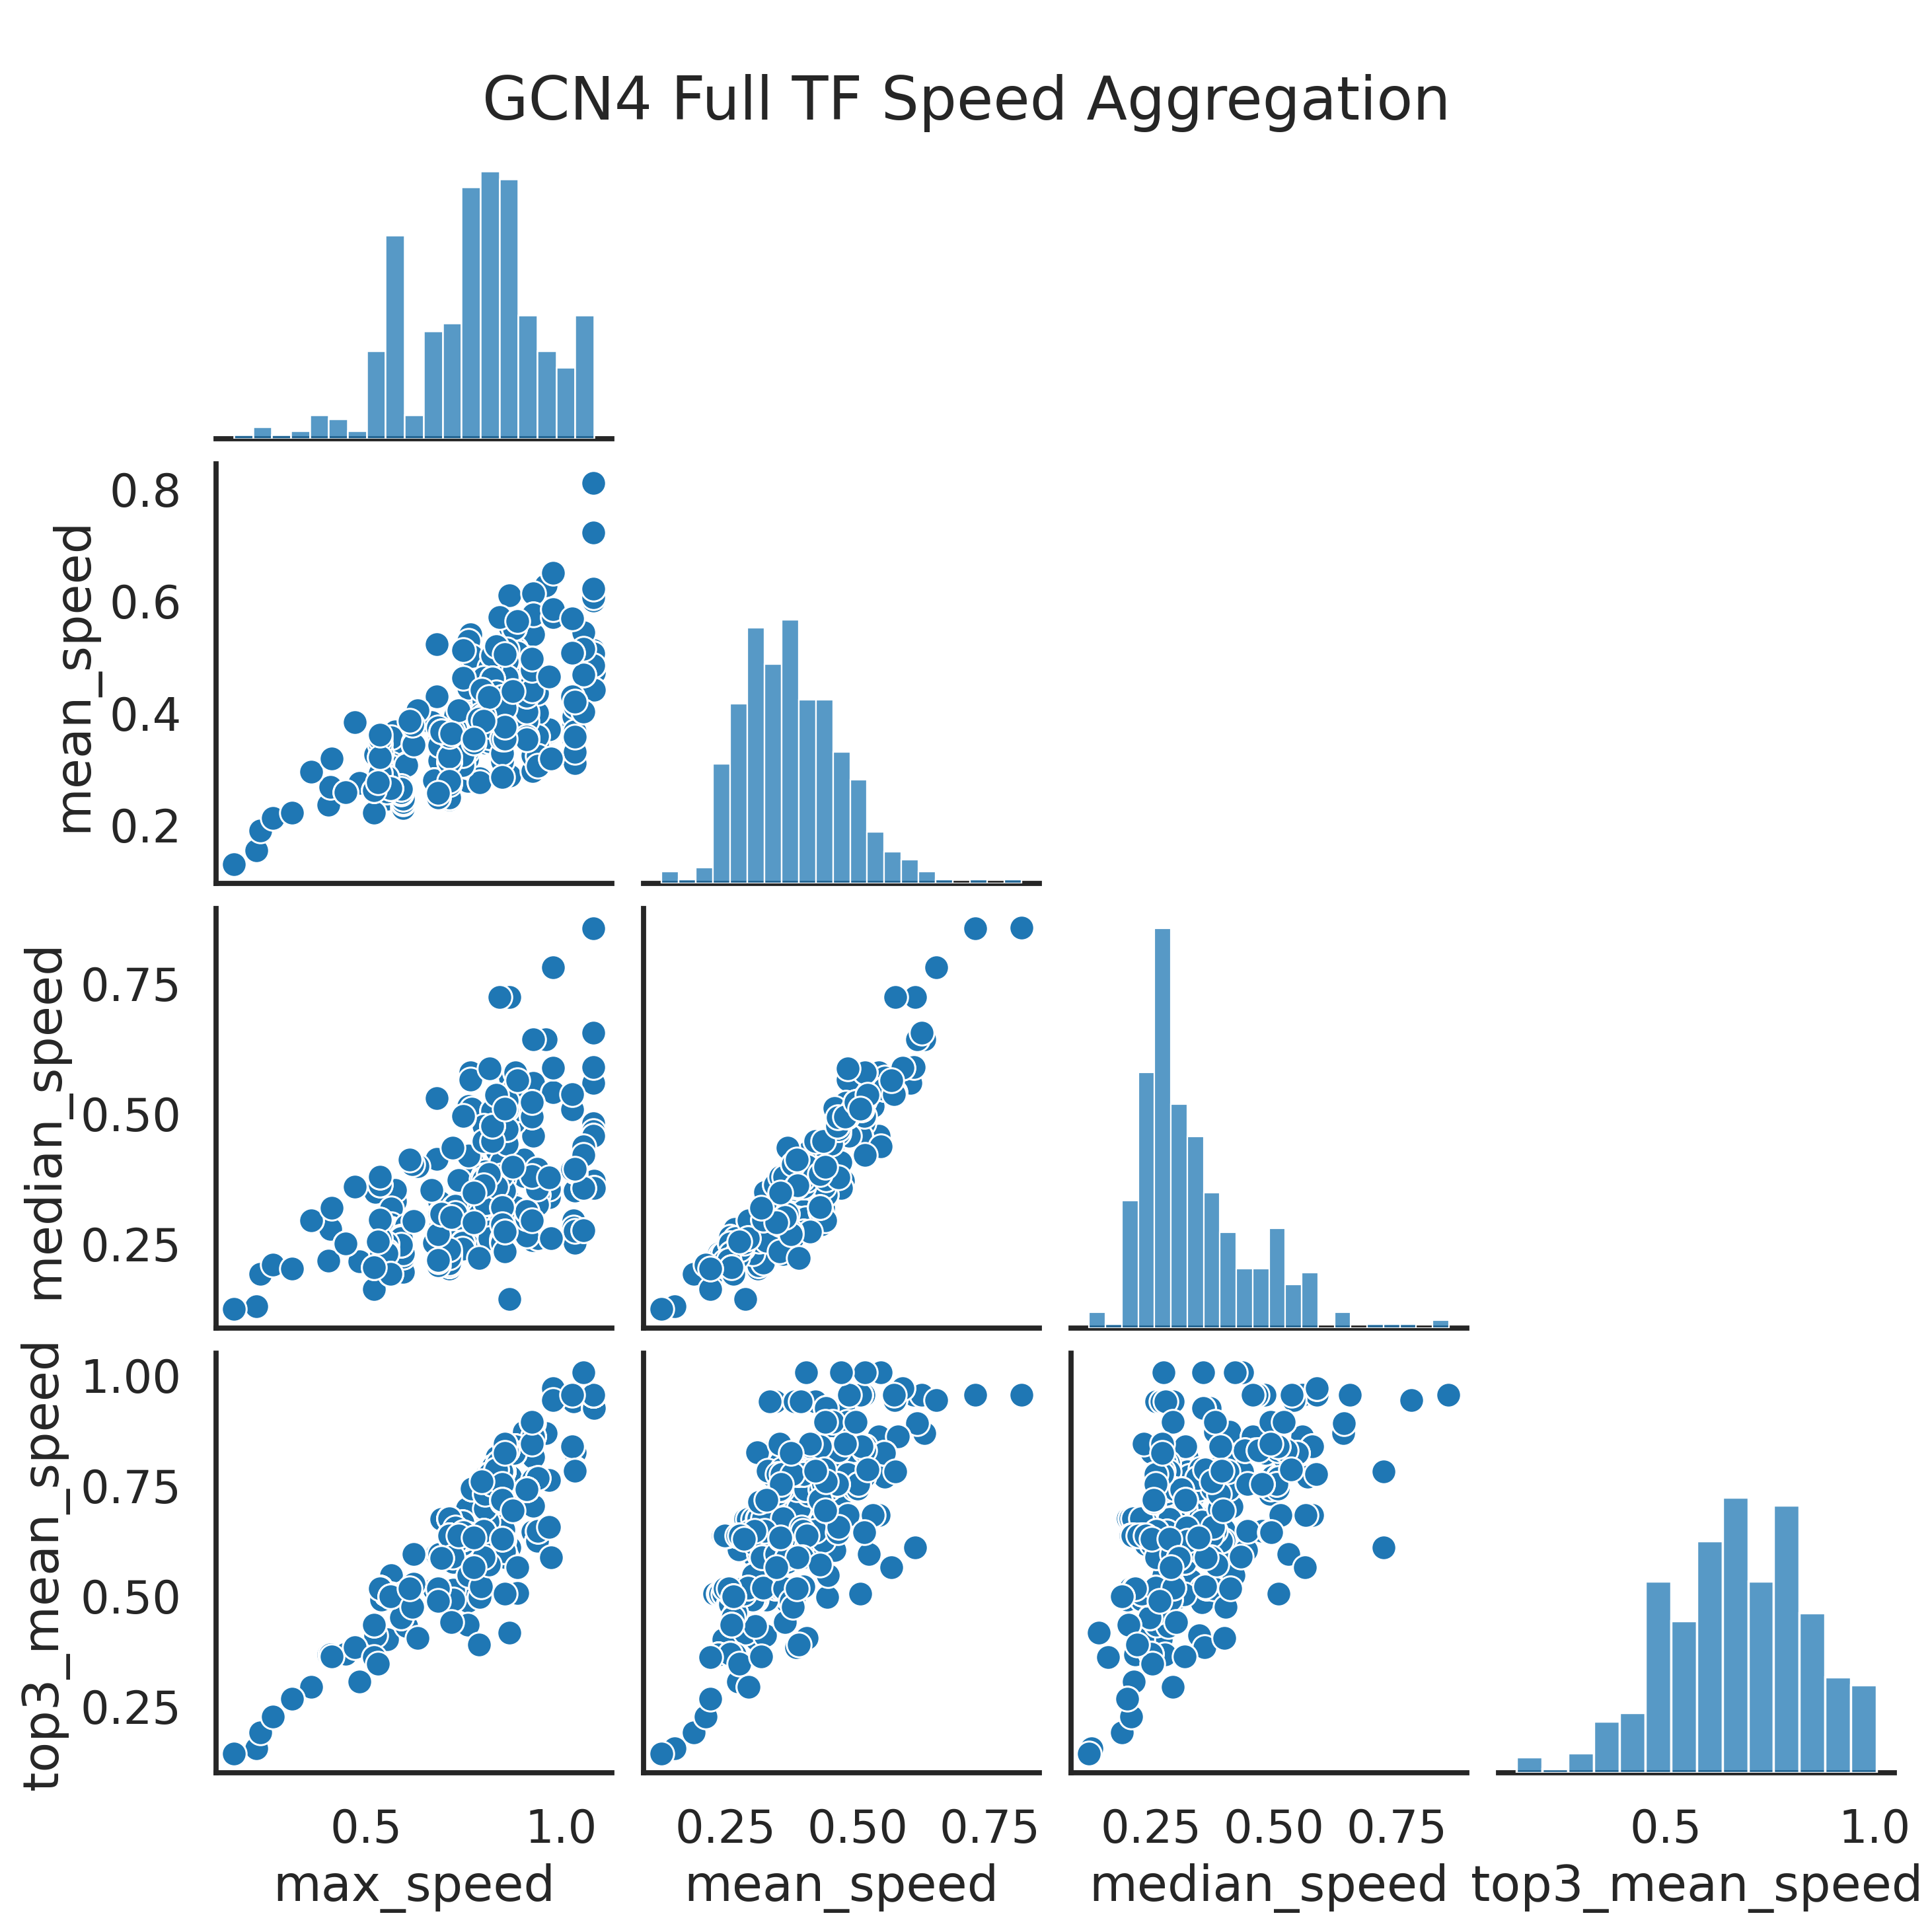

In [92]:
sns.set_context('talk')
sns.set_style('white')
sns.pairplot(gcn4_seq_df_with_max_speeds_suffic_cov[["max_speed", "mean_speed", "median_speed", "top3_mean_speed"]],
            corner=True)
plt.suptitle("GCN4 Full TF Speed Aggregation", y = 0.95)